# Parte I - Regime do rio

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter 
import calendar 
import locale 

In [3]:
# Importar dados
path = "C:\\ENS\\Obras_Hidraulicas"
dados = pd.read_excel(path+'\\Inputs\\Dados_Grupo_2.xlsx',
                      sheet_name = 'Classes',
                      header = 1
                     ).set_index('Classe') 

## Histograma (30 classes) 
Abscissa: vazão normalizada; ordenada: frequência relativa.

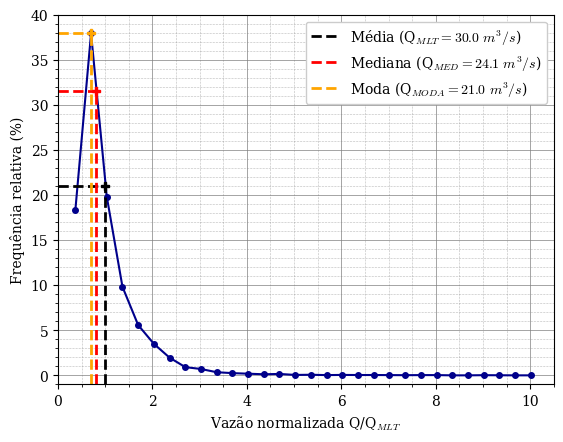

In [5]:
fig,ax = plt.subplots() 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'  

ax.plot(dados['Vazão normalizada Q/QMLT'], 
        dados['Freq. relativa (%)'], 
        marker = 'o', 
        markersize = 4, 
        color='darkblue')

# Q media (QMLT) 
qmlt = 21
ax.plot([0, 1], 
        [qmlt, qmlt],
        color='black',
        linestyle='--',
        linewidth=2,
        label = r'Média (Q$_{MLT} = 30.0\ m^3/s$)') 
ax.plot([1, 1], 
        [-1, qmlt],
        color='black',
        linestyle='--',
        linewidth=2) 
ax.plot(1, qmlt, 
        marker='P', 
        color='black',
        markersize=6)

# Q mediana
medianax = 0.8 
medianay = 31.5
ax.plot([0, medianax], 
        [medianay, medianay],
        color='red',
        linestyle='--',
        linewidth=2,
        label = r'Mediana (Q$_{MED} = 24.1\ m^3/s$)') 
ax.plot([medianax, medianax], 
        [-1, medianay],
        color='red',
        linestyle='--',
        linewidth=2) 
ax.plot(medianax, medianay, 
        marker='P', 
        color='red',
        markersize=6)

# Q moda
moday = dados['Freq. relativa (%)'].max()  
modax = dados.loc[dados['Freq. relativa (%)'] == moday, 
    'Vazão normalizada Q/QMLT'].iloc[0]
ax.plot([0, modax], 
        [moday, moday],
        color='orange',
        linestyle='--',
        linewidth=2,
        label = r'Moda (Q$_{MODA} = 21.0\ m^3/s$)') 
ax.plot([modax, modax], 
        [-1, moday],
        color='orange',
        linestyle='--',
        linewidth=2) 
ax.plot(modax, moday, 
        marker='P', 
        color='orange',
        markersize=6)

plt.xlabel("Vazão normalizada Q/Q$_{MLT}$")
plt.ylabel("Frequência relativa (%)")
plt.grid(True,
        which='major', 
        color='gray', 
        linestyle='-',
        linewidth=0.5)
plt.grid(True,
        which='minor', 
        color='gray', 
        linestyle=':',
        linewidth=0.4)
ax.minorticks_on()
plt.xlim(0, 10.5)
plt.ylim(-1, 40)
plt.legend(framealpha=1)
plt.savefig(path+'\\Outputs\\Histograma.png', bbox_inches='tight') 

## Curva de Permanência

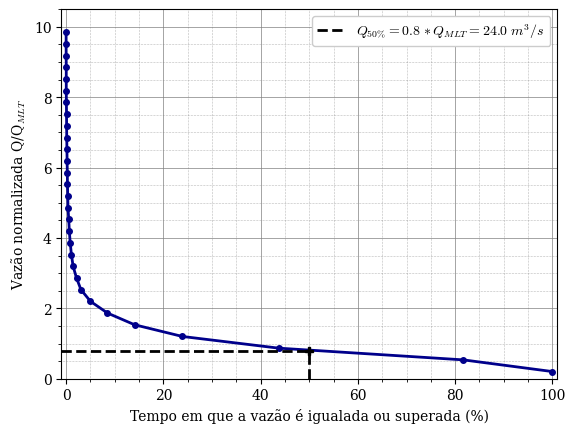

In [6]:
fig,ax = plt.subplots()
ax.plot(dados['Freq. acumulada (%)'], 
        dados['Vazão normalizada LI/QMLT'], 
        linewidth=2,
        marker = 'o', 
        markersize = 4, 
        color='darkblue') 

# Q50
Q50 = 0.8
ax.plot([-1, 50], 
        [Q50, Q50],
        color='black',
        linestyle='--',
        linewidth=2,
        label=rf'$Q_{{50\%}}={Q50:.1f}\,*Q_{{MLT}}={Q50*30:.1f}\ m^3/s$') 
ax.plot([50, 50], 
        [0, Q50],
        color='black',
        linestyle='--',
        linewidth=2) 
ax.plot(50, Q50, 
        marker='P', 
        color='black',
        markersize=6)

plt.xlabel("Tempo em que a vazão é igualada ou superada (%)")
plt.ylabel("Vazão normalizada Q/Q$_{MLT}$")
plt.grid(True,
        which='major', 
        color='gray', 
        linestyle='-',
        linewidth=0.5)
plt.grid(True,
        which='minor', 
        color='gray', 
        linestyle=':',
        linewidth=0.4)
ax.minorticks_on()
plt.ylim(0, 10.5)
plt.xlim(-1, 101)
plt.legend(framealpha=1)
plt.savefig(path+'\\Outputs\\Curva_perm1.png', bbox_inches='tight') 

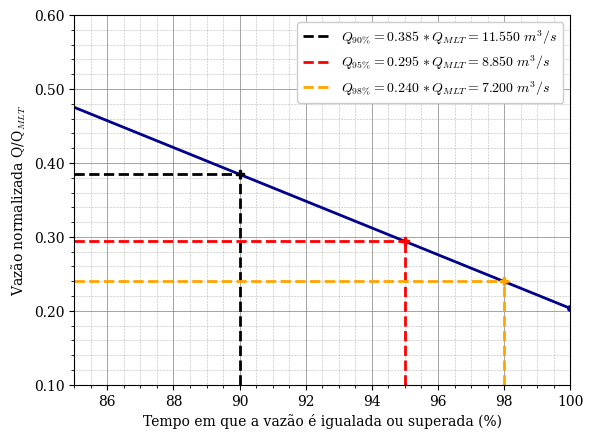

In [7]:
fig,ax = plt.subplots()
ax.plot(dados['Freq. acumulada (%)'], 
        dados['Vazão normalizada LI/QMLT'], 
        linewidth=2,
        marker = 'o', 
        markersize = 4, 
        color='darkblue') 

# Q90
Q90 = 0.385
ax.plot([85, 90], 
        [Q90, Q90],
        color='black',
        linestyle='--',
        linewidth=2,
        label=rf'$Q_{{90\%}}={Q90:.3f}\,*Q_{{MLT}}={Q90*30:.3f}\ m^3/s$') 
ax.plot([90, 90], 
        [0.1, Q90],
        color='black',
        linestyle='--',
        linewidth=2) 
ax.plot(90, Q90, 
        marker='P', 
        color='black',
        markersize=6)

# Q95
Q95 = 0.295
ax.plot([85, 95], 
        [Q95, Q95],
        color='red',
        linestyle='--',
        linewidth=2,
        label=rf'$Q_{{95\%}}={Q95:.3f}\,*Q_{{MLT}}={Q95*30:.3f}\ m^3/s$') 
ax.plot([95, 95], 
        [0.1, Q95],
        color='red',
        linestyle='--',
        linewidth=2) 
ax.plot(95, Q95, 
        marker='P', 
        color='red',
        markersize=6)

# Q98
Q98 = 0.240
ax.plot([85, 98], 
        [Q98, Q98],
        color='orange',
        linestyle='--',
        linewidth=2,
        label=rf'$Q_{{98\%}}={Q98:.3f}\,*Q_{{MLT}}={Q98*30:.3f}\ m^3/s$') 
ax.plot([98, 98], 
        [0.1, Q98],
        color='orange',
        linestyle='--',
        linewidth=2) 
ax.plot(98, Q98, 
        marker='P', 
        color='orange',
        markersize=6)

plt.xlabel("Tempo em que a vazão é igualada ou superada (%)")
plt.ylabel("Vazão normalizada Q/Q$_{MLT}$")
plt.grid(True,
        which='major', 
        color='gray', 
        linestyle='-',
        linewidth=0.5)
plt.grid(True,
        which='minor', 
        color='gray', 
        linestyle=':',
        linewidth=0.4)
ax.minorticks_on()
plt.ylim(0.1, 0.6)
plt.xlim(85, 100)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.legend(framealpha=1)
plt.savefig(path+'\\Outputs\\Curva_perm2.png', bbox_inches='tight') 

## Hidrogramas

In [8]:
# Importar e reorganizar dados 
dados = pd.read_excel(path+'\\Inputs\\Dados_Grupo_2.xlsx',
                      sheet_name = 'Dados diários',
                      nrows = 10959,
                      usecols="A:B"
                     ).set_index('DATA')
dados['log(VAZAO)'] = np.log10(dados['VAZAO'])

media_mensal = dados.resample('ME').mean()
media_anual = dados.resample('YE').mean() 

 + Adicionar intervalo +-DP no hidrograma anual 

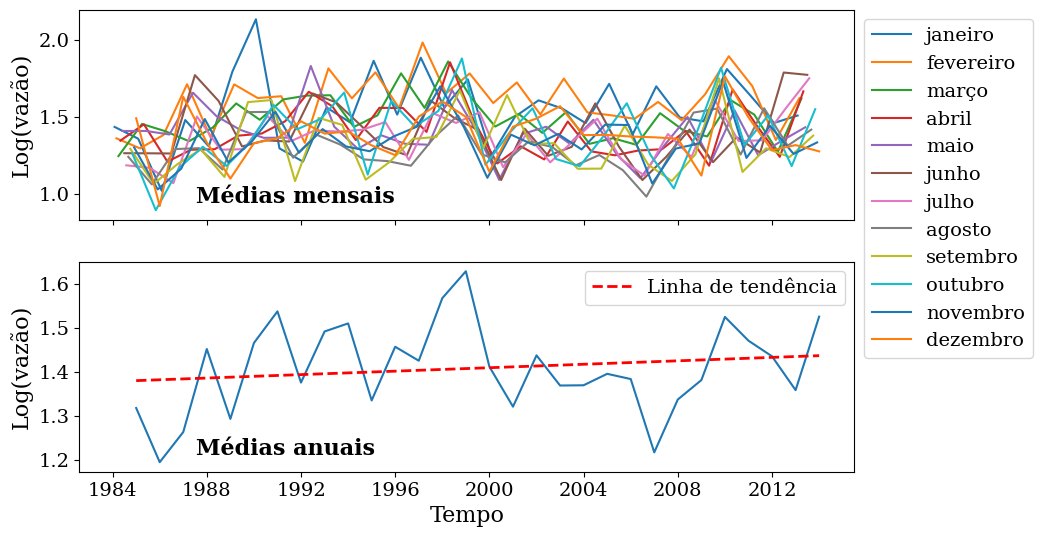

In [75]:
# Hidrogramas mensal e anual 
fig,ax = plt.subplots(2, sharex=True, figsize=(10, 6)) 
'''
for mes in range(1, 13):
    dados_mes = media_mensal[media_mensal.index.month == mes]
    ax[0].plot(dados_mes.index, dados_mes['log(VAZAO)'], 
            label=calendar.month_name[mes])
'''
locale.setlocale(locale.LC_TIME, "pt_BR.UTF-8")  
for mes in range(1, 13):
    nome_mes = calendar.month_name[mes]  
    dados_mes = media_mensal[media_mensal.index.month == mes]
    ax[0].plot(dados_mes.index, dados_mes['log(VAZAO)'], label=nome_mes)
ax[0].set_ylabel('Log(vazão)', fontsize=16)
ax[0].legend(fontsize=14, loc="upper left", 
             bbox_to_anchor=(1, 1))

ax[1].plot(media_anual['log(VAZAO)'])
ax[1].set_ylabel('Log(vazão)', fontsize=16)
# Ajuste linear 
x = media_anual.index.year.astype(float)   
y = media_anual['log(VAZAO)'] 
a, b = np.polyfit(x, y, 1)  
ax[1].plot(media_anual.index, a*x + b,
           linestyle='--',
           linewidth=2,
           color='red',
           label='Linha de tendência') 
ax[1].legend(fontsize=14) 

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.xlabel('Tempo', fontsize=16) 
font = {'fontsize':16, 'fontweight':'bold'} 
plt.text(0.15, 1.28,'Médias mensais', font, transform=plt.gca().transAxes)
plt.text(0.15, 0.08,'Médias anuais', font, transform=plt.gca().transAxes)
plt.savefig(path+'\\Outputs\\Hidrogramas.png', bbox_inches='tight') 